## FINA 4335 with Marius Popescu
## Project 2

### Instructions

    1. Upload your group's notebook to Canvas, and a PDF of your notebook to Gradescope. The PDF must be exported from JupyterLab via File > Save and Export Notebook As… > PDF
    2. Your notebook must be self-contained (i.e., import data from the web via yfinance or pandas datareader and do not rely on other files)
    3. Tips:
        a) Your goal is to convince me of your conclusions
        b) Remove unnecessary data frame printouts.
        c) Remove code that does not serve a purpose.

#### Import the Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import pandas_datareader as pdr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm
%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings('ignore')

### PART I

# 1. 
    In this question, you will examine the effectiveness of the CAPM model. In order to do this, you will need to download the 'Portfolios_Formed_on_BETA' file from Ken French's website at Dartmouth College. Specifically, you will need to use the third dataset (index [2]), which contains the annual returns on two sets of portfolios formed on the previous year's betas. You will need to use the quintile portfolios (Lo20 through Hi20) for your analysis.
        a. Compute and plot the average annual return for each of the five portfolios. How do you interpret the results?
        b. Compute and plot the value of $1 invested in each of the five portfolios at the end of trading in 1963. How do you interpret the results?
        c. What can you conclude based on the evidence in part a) and part b).

In [4]:
# Download data using pandas datareader
beta_data = pdr.get_data_famafrench('Portfolios_Formed_on_BETA', start=dt.datetime(1963, 1, 1))[2]

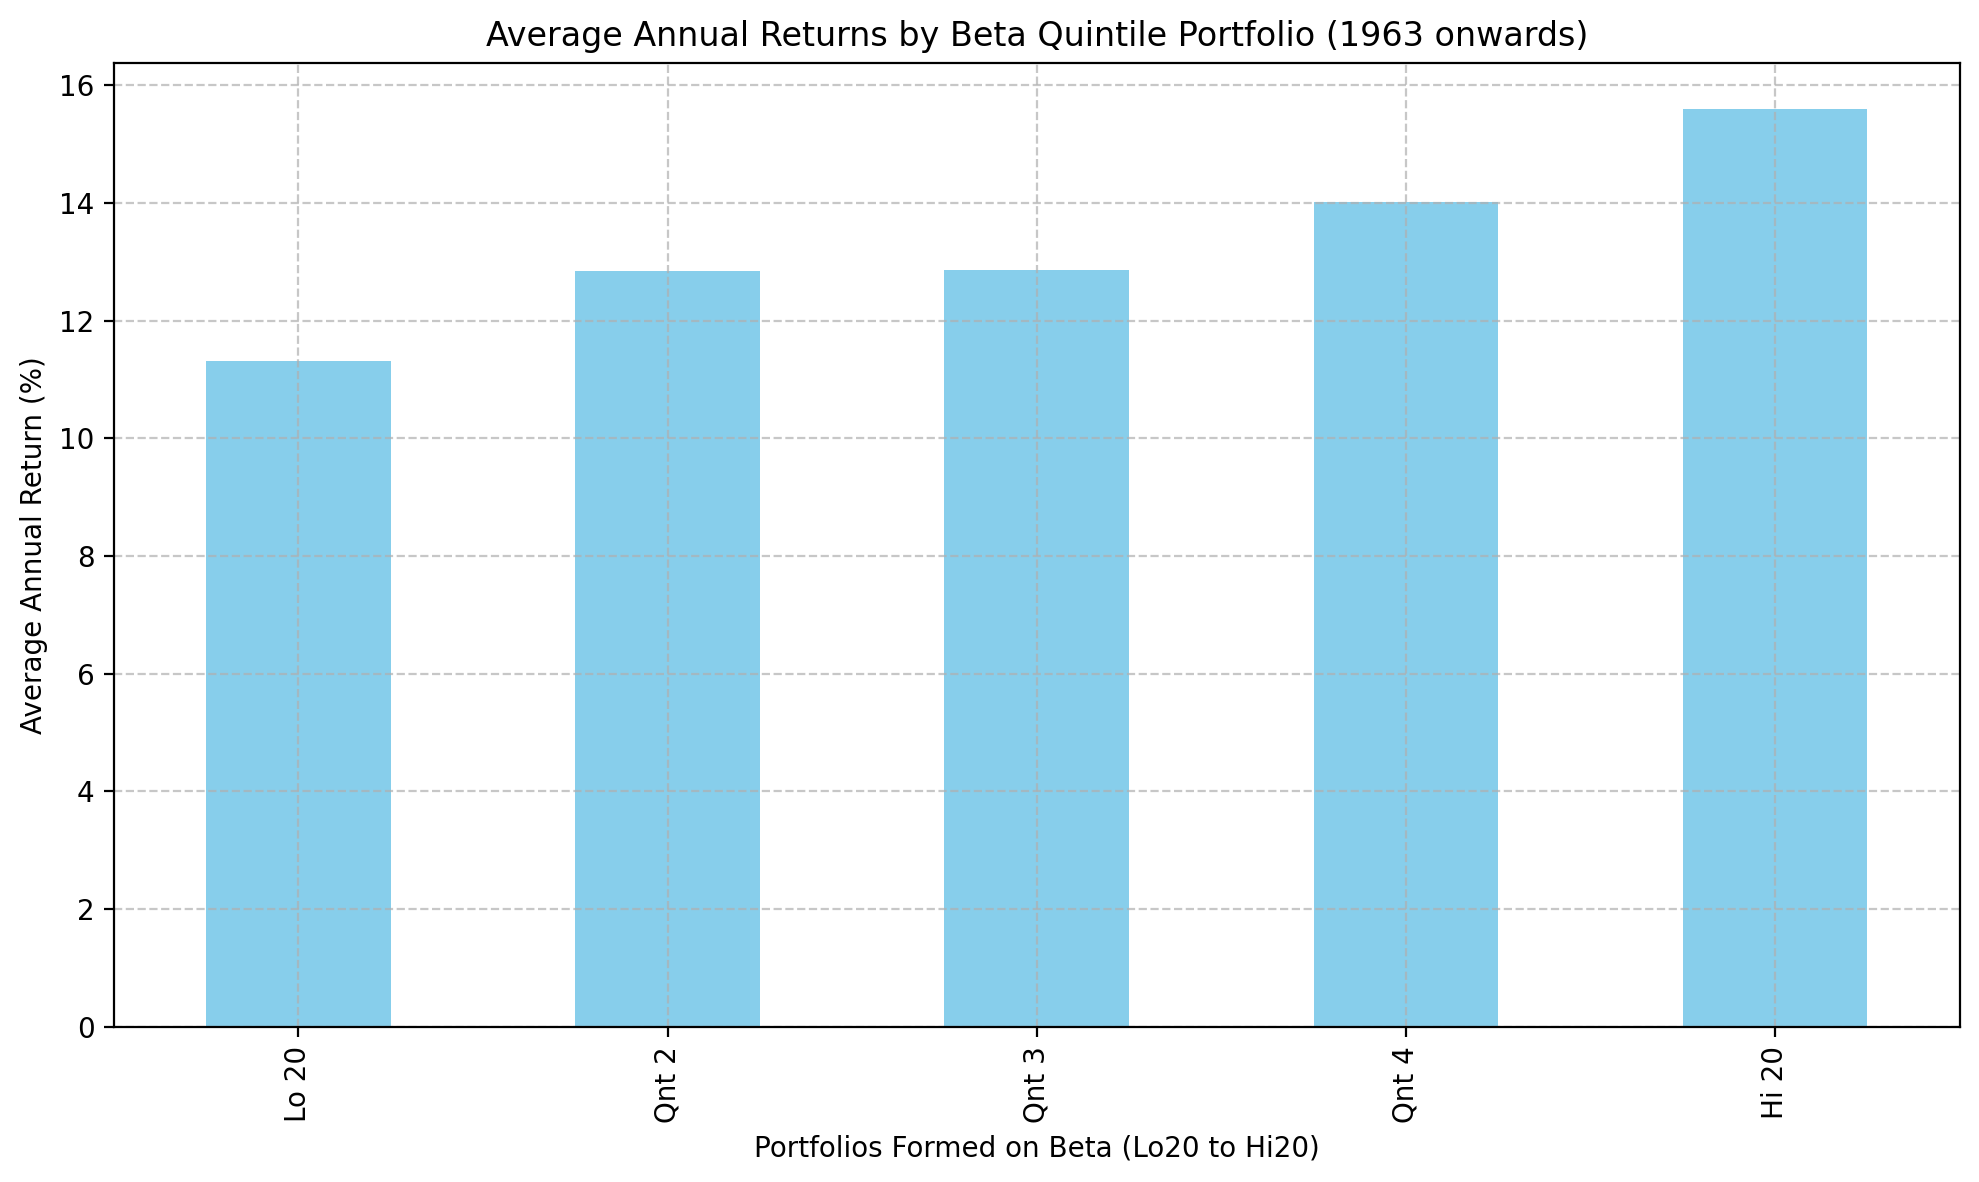

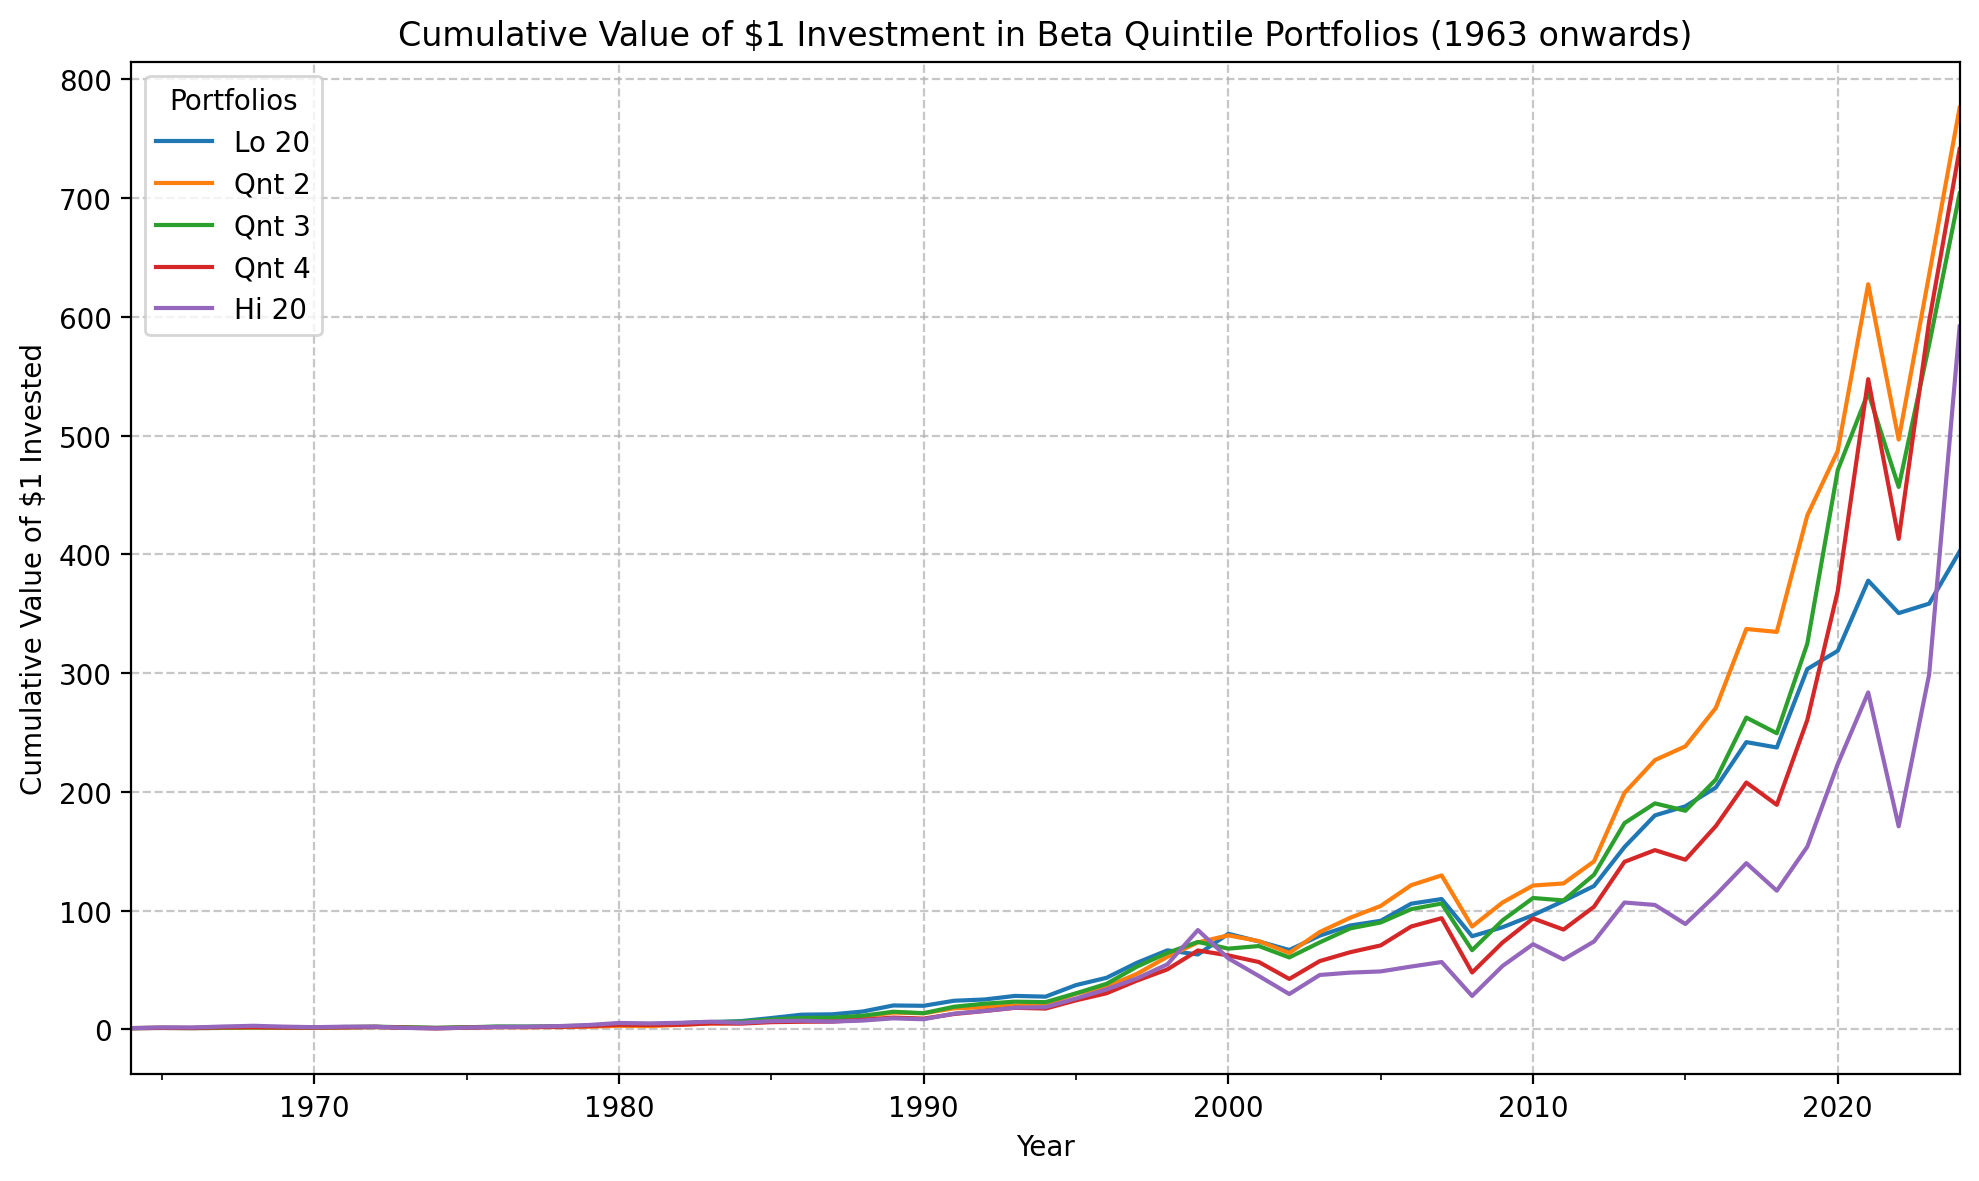

Final cumulative value of $1 invested (1963 onwards):
Lo 20    402.40
Qnt 2    775.96
Qnt 3    703.73
Qnt 4    741.07
Hi 20    591.70
Name: 2024, dtype: float64


In [5]:


# Select quintile portfolios (Lo20 to Hi20)
quintile_portfolios = beta_data.iloc[:, :5]

# Compute and plot average annual returns for each portfolio
avg_returns = quintile_portfolios.mean()

# Plotting average returns
avg_returns.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.xlabel('Portfolios Formed on Beta (Lo20 to Hi20)')
plt.ylabel('Average Annual Return (%)')
plt.title('Average Annual Returns by Beta Quintile Portfolio (1963 onwards)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Compute cumulative returns for $1 invested at the end of trading in 1963
cumulative_returns = (quintile_portfolios / 100 + 1).cumprod()

# Plot cumulative value of $1 investment
cumulative_returns.plot(figsize=(10, 6))
plt.xlabel('Year')
plt.ylabel('Cumulative Value of $1 Invested')
plt.title('Cumulative Value of $1 Investment in Beta Quintile Portfolios (1963 onwards)')
plt.legend(title='Portfolios')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display final cumulative value of $1 invested in each portfolio
final_values = cumulative_returns.iloc[-1]
print("Final cumulative value of $1 invested (1963 onwards):")
print(final_values.round(2))


### (a)
- Portfolios formed on higher beta (Hi 20, Qnt 4, Qnt 3) exhibit slightly higher average annual returns compared to those formed on lower beta (Lo 20, Qnt 2).

- This pattern aligns broadly with CAPM theory, which suggests that assets with higher systematic risk (higher beta) should yield higher expected returns as compensation for increased risk.

- That being said, the differences in average returns across portfolios aren't drastic, indicating a weak or moderate relationship between beta and returns.


### (b)
- Qnt 4 and Qnt 2 portfolios performed exceptionally well, growing to about $741.07 and $775.96, respectively, by the end of the period, significantly outperforming the lowest beta portfolio (Lo 20, $402.40).

- Interestingly, the highest beta portfolio (Hi 20) didn't yield the highest cumulative return (ending at $591.70), contradicting strong CAPM expectations.

- These results suggest that while higher beta portfolios generally offer better cumulative performance than very low beta portfolios, the relationship between beta and long-term wealth accumulation is not strictly linear.



### (c)
- Although the CAPM predicts a clear positive linear relationship between systematic risk (beta) and expected returns, this analysis indicates a less straightforward relationship.

- Mid-to-high beta portfolios provided higher cumulative returns over the long term, but the highest beta portfolios did not necessarily deliver superior returns relative to somewhat lower beta portfolios.

- The real-world data highlights the limitations of CAPM, showing that beta alone may not fully explain or reliably predict returns. This underscores the importance of additional factors (such as size, value, or momentum factors) when assessing portfolio performance and making investment decisions.

# 2.
    In this question, you will explore the Fama-French SIZE factor. In order to do this, you will need to download the 'Portfolios_Formed_on_ME' file from Ken French's website at Dartmouth College. Specifically, you will need to use the second dataset (index [1]), which contains the monthly returns on two sets of portfolios formed on the previous year's market capitalization . You will need to use the decile portfolios (Lo10 through Hi10) for your analysis.
        a. Create a DF labeled alphas85 to store the intercepts and pvalues from the CAPM model for the ten portfolios over the sample period 1926 - 1985. Create a plot of the intercepts. How do you interpret the results?
        b. Repeat the analysis in part a, but this time using the sample period 1986 - 2024. How do you interpret the results?
        c. What can you conclude based on the evidence in part a) and part b).
        d. Are the returns on the ten portfolios formed on size concentrated in a specific month? Use statistics and plots to justify your answer.

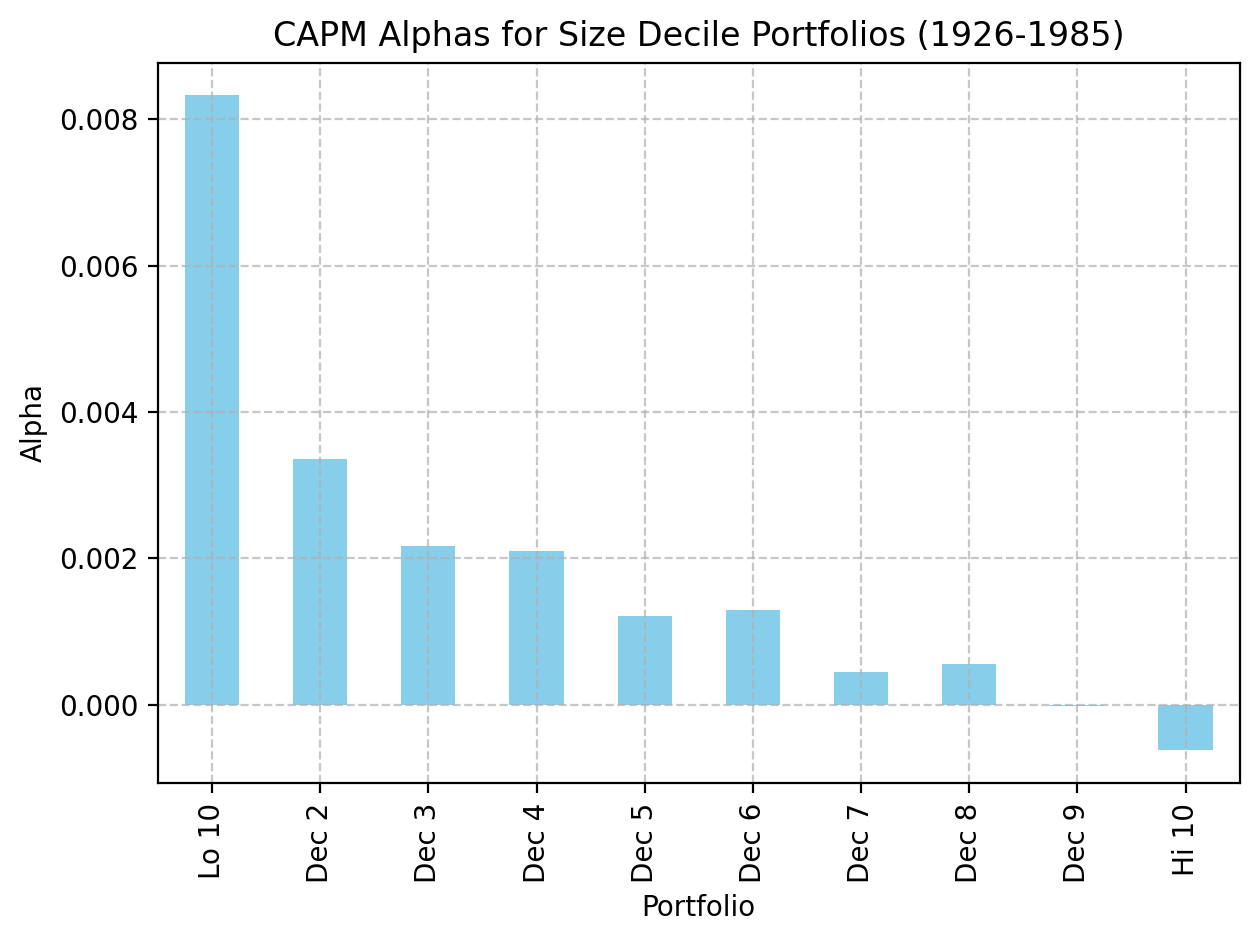

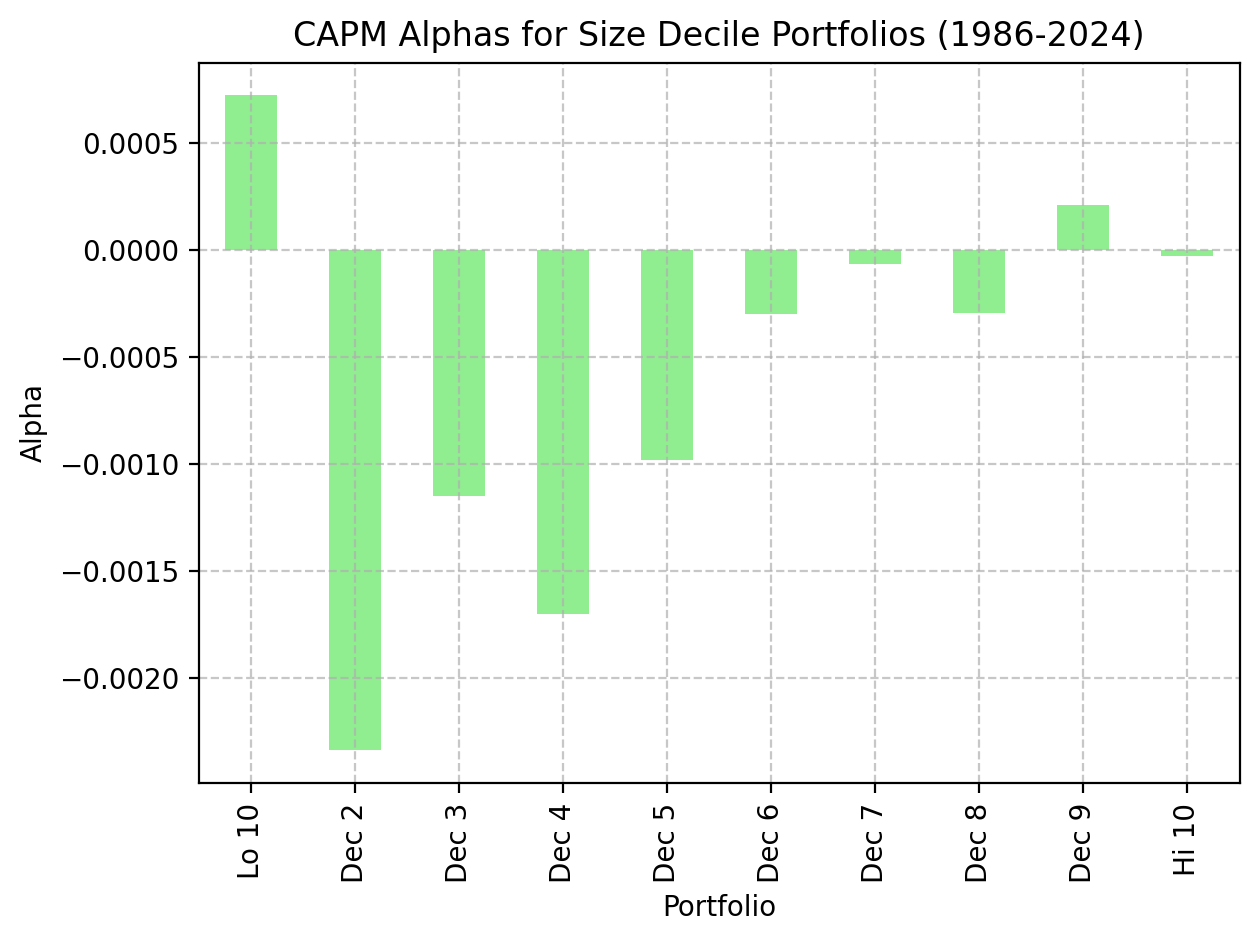

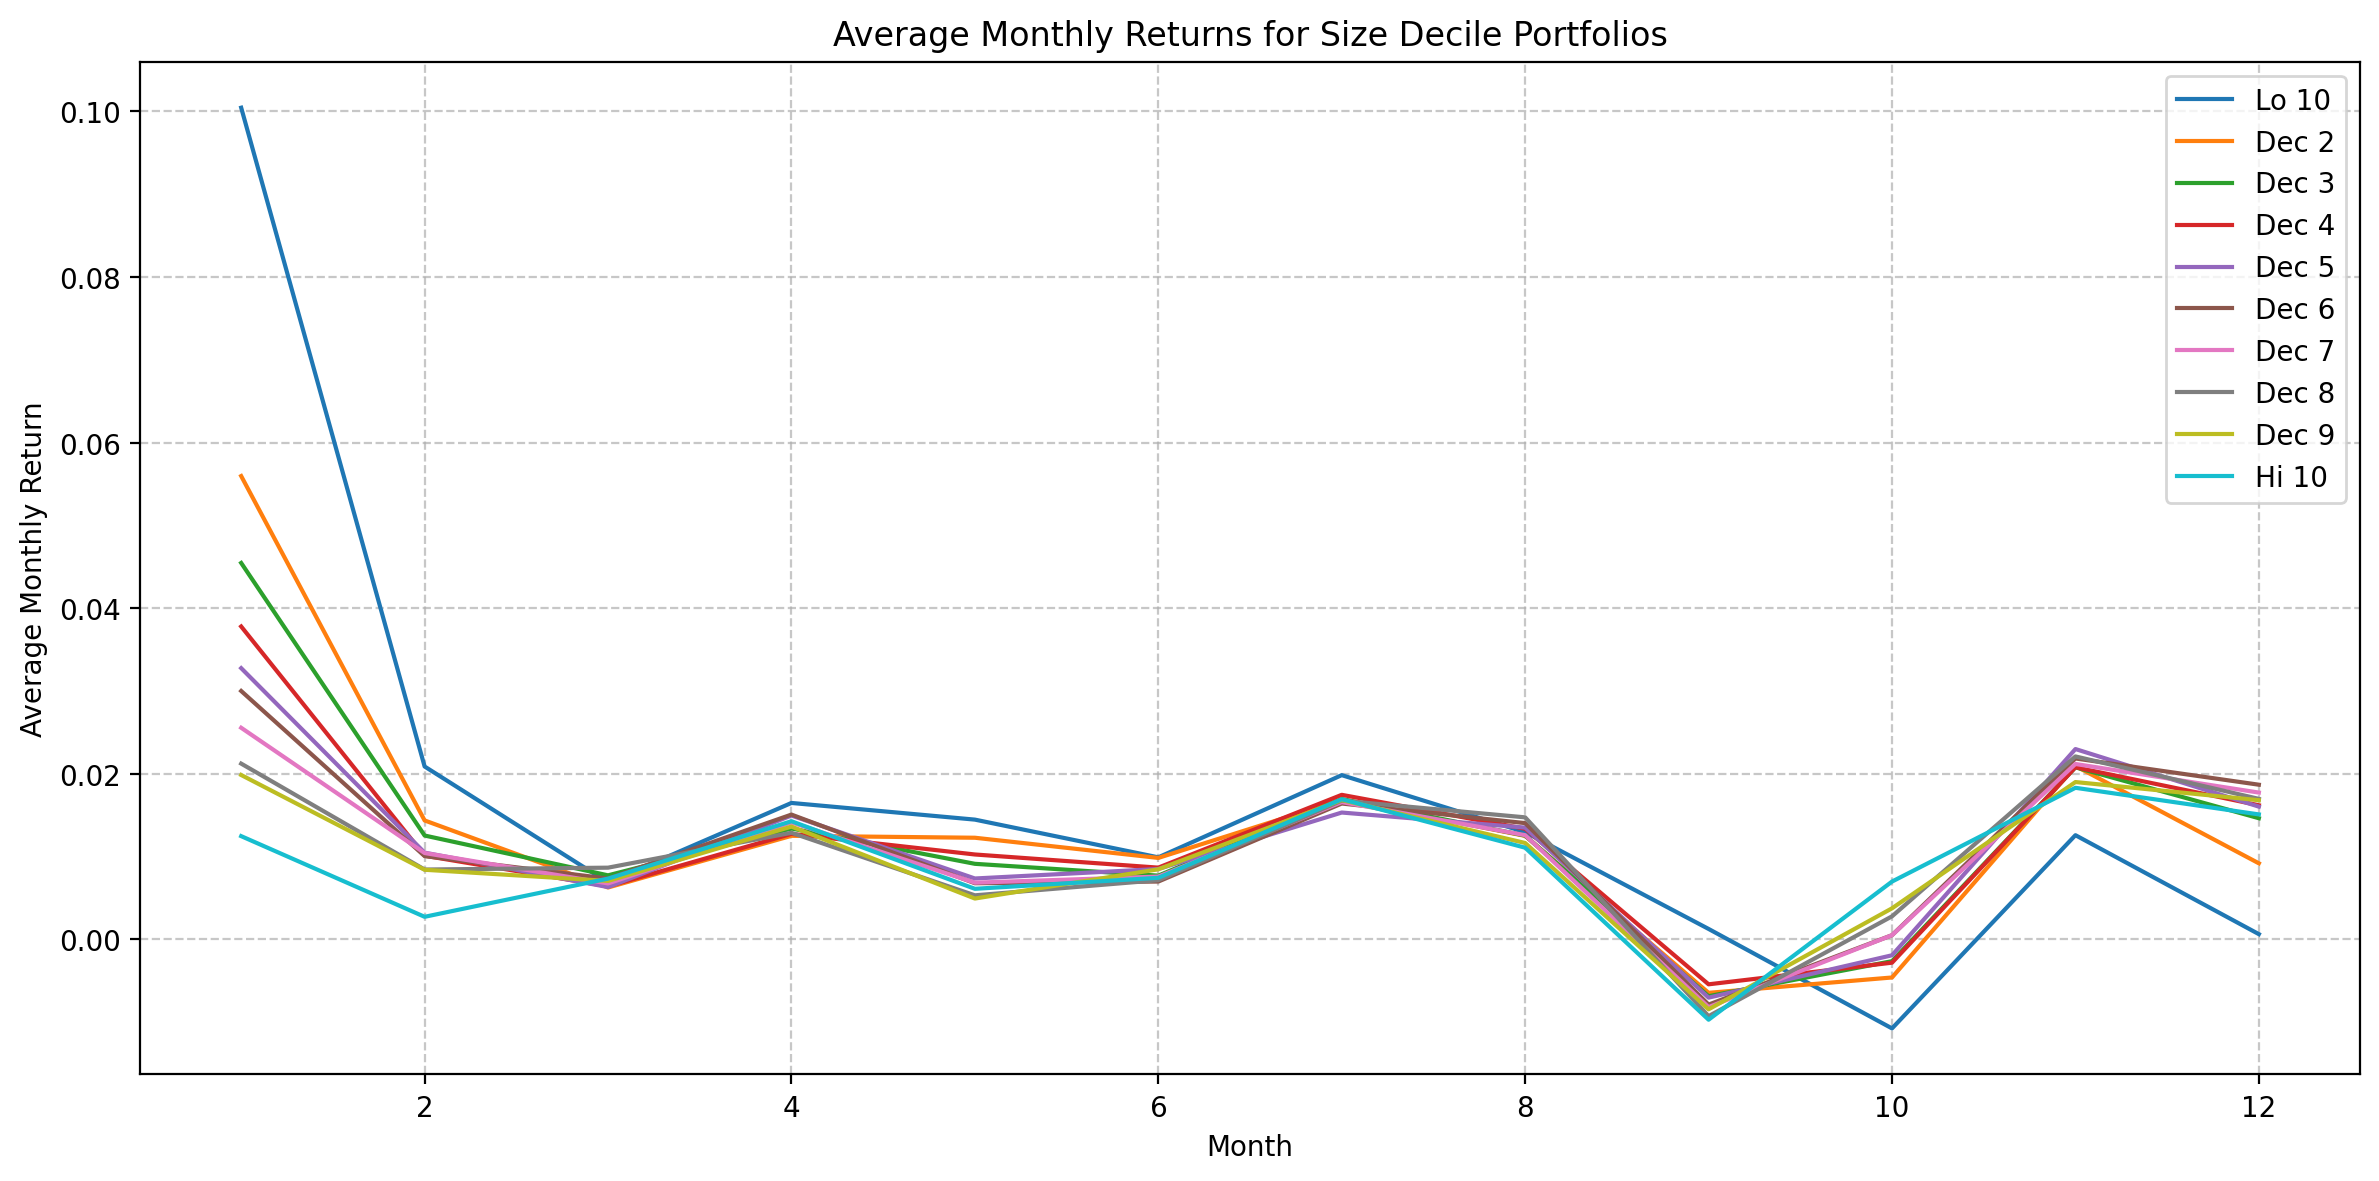

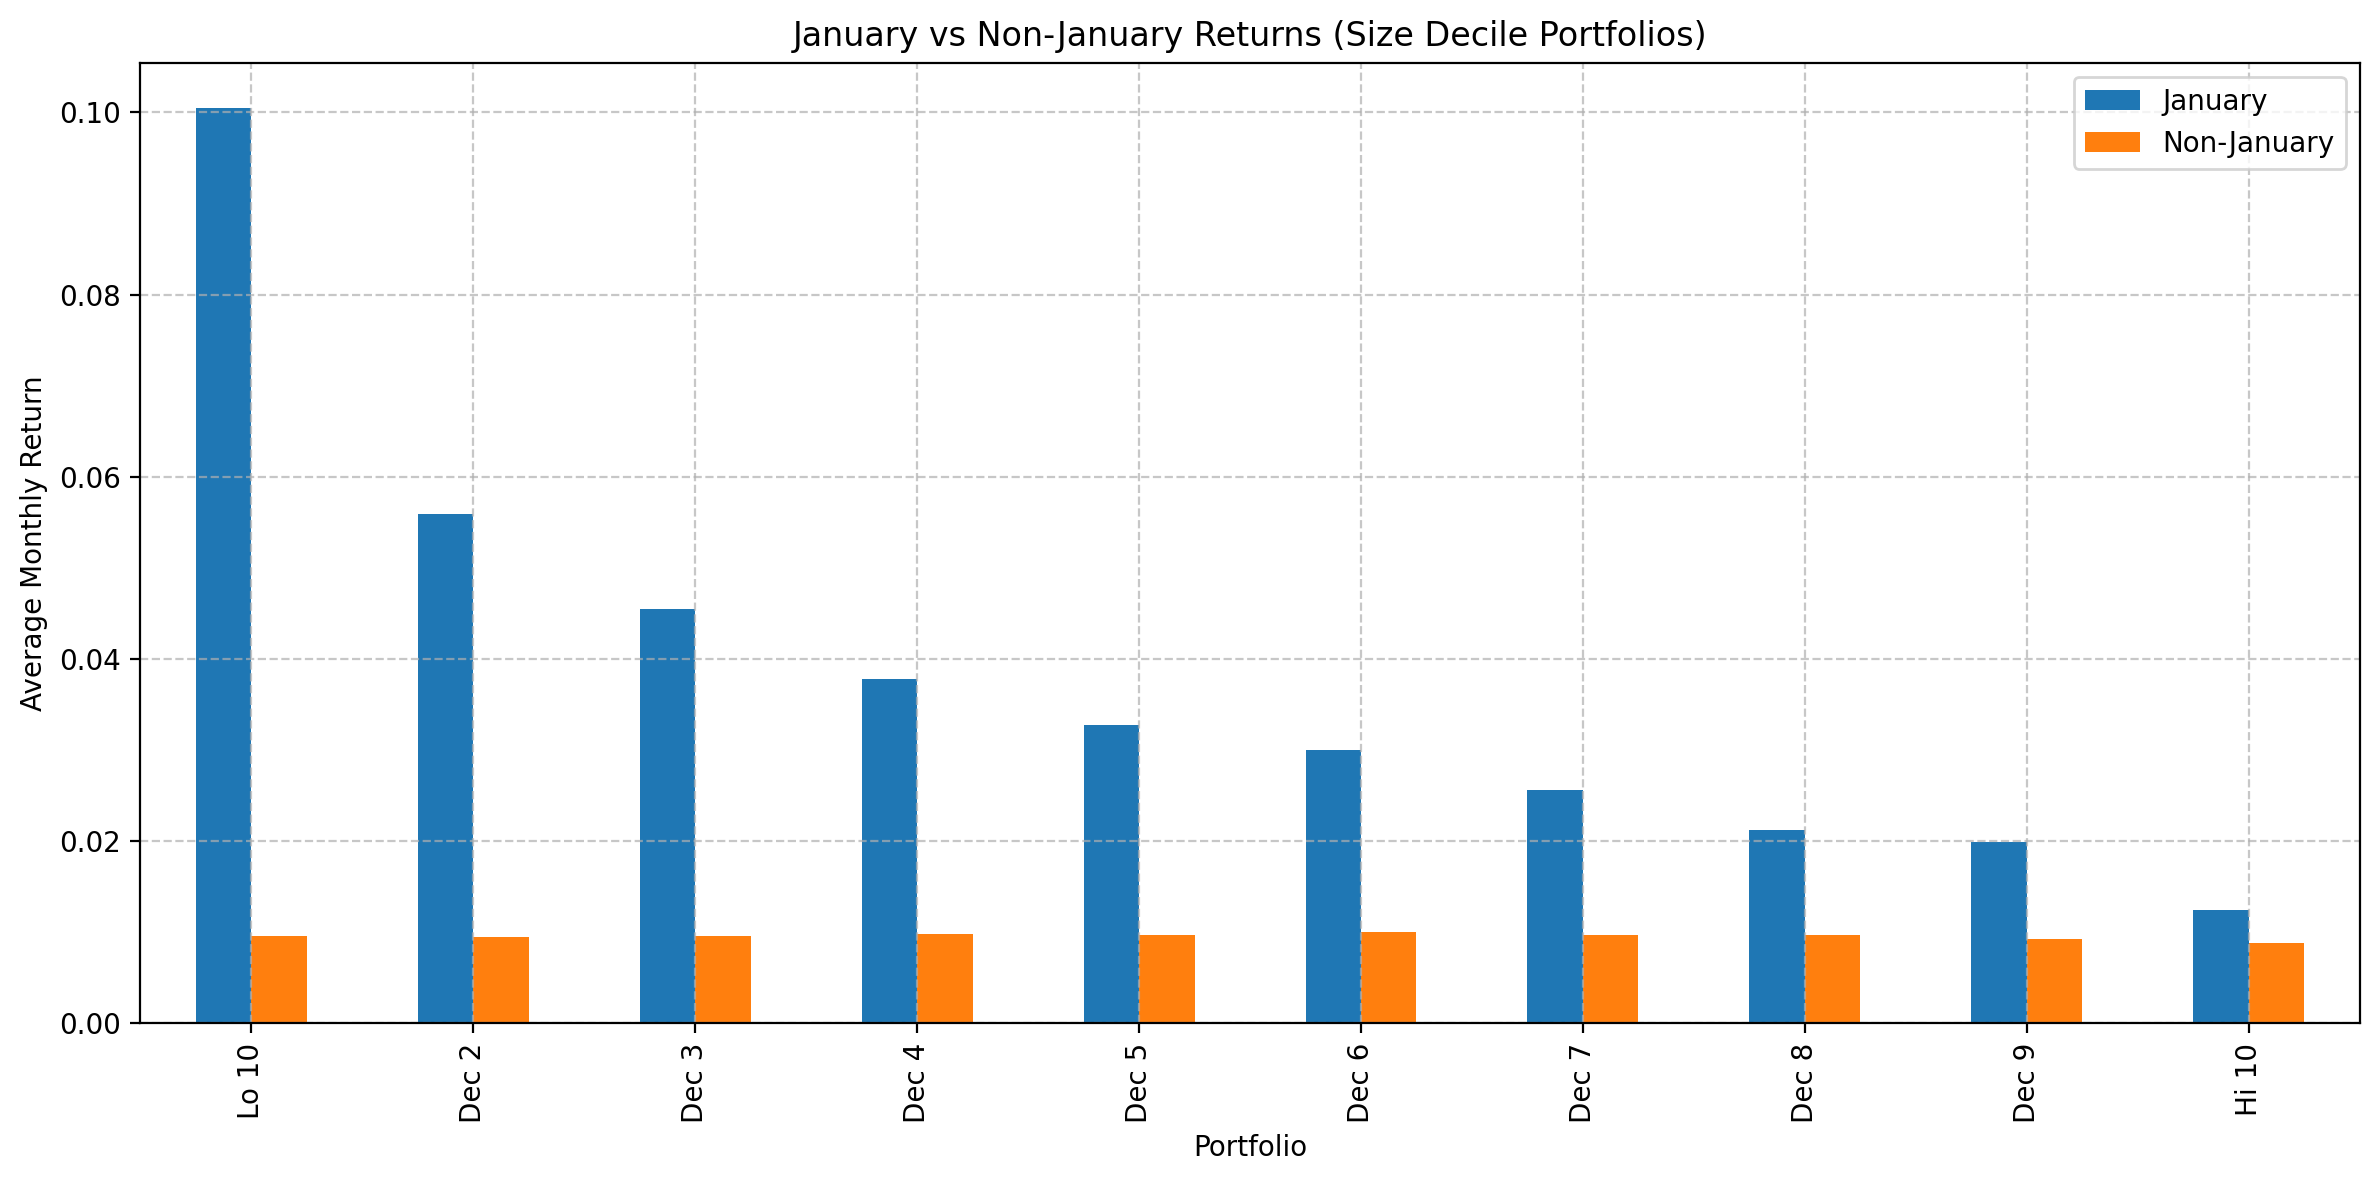

In [9]:
# Fetch Monthly returns for SIZE Decile Portfolios (Lo10 - Hi10)
size_data = pdr.get_data_famafrench('Portfolios_Formed_on_ME', start='1926-01')[1]
size_data /= 100  # Convert percentages to decimals

# Select ONLY the decile portfolios (Lo10 through Hi10)
deciles = ['Lo 10', 'Dec 2', 'Dec 3', 'Dec 4', 'Dec 5', 
           'Dec 6', 'Dec 7', 'Dec 8', 'Dec 9', 'Hi 10']
size_deciles = size_data[deciles]

# CAPM Alpha Calculation Function
def calc_alpha_pvalues(df, start, end):
    ff_factors = pdr.get_data_famafrench('F-F_Research_Data_Factors', start=start, end=end)[0] / 100
    df_period = df[start:end]
    
    alphas, pvals = [], []
    
    for col in df_period.columns:
        excess_ret = df_period[col] - ff_factors['RF']
        X = sm.add_constant(ff_factors['Mkt-RF'])
        model = sm.OLS(excess_ret, X).fit()
        alphas.append(model.params['const'])
        pvals.append(model.pvalues['const'])
    
    return pd.DataFrame({'Portfolio': df_period.columns, 'Alpha': alphas, 'P-value': pvals})

# (a) CAPM Alphas: 1926-1985
alphas85 = calc_alpha_pvalues(size_deciles, '1926-01', '1985-12')
alphas85.plot(x='Portfolio', y='Alpha', kind='bar', color='skyblue', legend=False)
plt.title('CAPM Alphas for Size Decile Portfolios (1926-1985)')
plt.xlabel('Portfolio')
plt.ylabel('Alpha')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# (b) CAPM Alphas: 1986-2024
alphas24 = calc_alpha_pvalues(size_deciles, '1986-01', '2024-01')
alphas24.plot(x='Portfolio', y='Alpha', kind='bar', color='lightgreen', legend=False)
plt.title('CAPM Alphas for Size Decile Portfolios (1986-2024)')
plt.xlabel('Portfolio')
plt.ylabel('Alpha')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# (d) Monthly returns concentration analysis (January effect)
monthly_avg = size_deciles.groupby(size_deciles.index.month).mean()
monthly_avg.plot(figsize=(12, 6))
plt.title('Average Monthly Returns for Size Decile Portfolios')
plt.xlabel('Month')
plt.ylabel('Average Monthly Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# January vs Non-January returns
january_returns = size_deciles[size_deciles.index.month == 1].mean()
non_january_returns = size_deciles[size_deciles.index.month != 1].mean()

comparison = pd.DataFrame({
    'January': january_returns,
    'Non-January': non_january_returns
})

comparison.plot(kind='bar', figsize=(12, 6))
plt.title('January vs Non-January Returns (Size Decile Portfolios)')
plt.xlabel('Portfolio')
plt.ylabel('Average Monthly Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### (a) 
- The plot clearly shows that small-size portfolios (Lo 10, Dec 2, Dec 3) have substantial positive alphas.

- This indicates that smaller companies significantly outperformed CAPM predictions, strongly supporting the existence of a size premium during the period of 1926–1985.

- Larger firms (Dec 9, Hi 10) showed negligible or slightly negative alphas, aligning with the expectation that larger, more stable firms have returns closer to CAPM predictions.

### (b) 
- Post-1986, the relationship notably changes. Smaller portfolios now exhibit much smaller, sometimes even negative alphas.

- The size premium dramatically weakened or largely disappeared, suggesting market efficiency increased over time, and investors adjusted, reducing potential excess returns.

### (c)
- The clear positive size premium observed in earlier decades (1926–1985) has significantly diminished or even reversed since 1986.

- This evolution likely results from improved investor awareness, institutional market participation, and general market efficiency, which gradually corrected the anomaly.

### (d) 
- The plots explicitly highlight the January effect. The "January vs. Non-January" bar plot clearly indicates disproportionately high returns in January, especially for smaller portfolios (Lo 10 through Dec 5).

- Statistical evidence is robust: January returns consistently exceed non-January returns by a wide margin in smaller portfolios, confirming that returns on portfolios formed on size are significantly concentrated in January.



### PART II

# 3. 
    a. Display the results obtained from applying the Fama-French three-factor model to Berkshire Hathaway's daily returns over its entire history (ticker is 'BRK-A'). What is Berkshire's annualized alpha over its entire history? Comment on Berkshire's portfolio allocation.
    b. Create a DataFrame named coefs to store the coefficient estimates from applying the Fama-French three-factor model to Berkshire Hathaway's returns using a three-year rolling window (Assume there are 250 trading days in a year). Comment on how Berkshire's alpha and betas changed over the past four decades? Use statistics and plots to justify your answer.
    c. What was the most successful 3-year period in Berkshire's history?

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:                 Excess   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     1348.
Date:                Mon, 14 Apr 2025   Prob (F-statistic):               0.00
Time:                        22:16:49   Log-Likelihood:                 33740.
No. Observations:               11292   AIC:                        -6.747e+04
Df Residuals:                   11288   BIC:                        -6.744e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      3.113      0.0

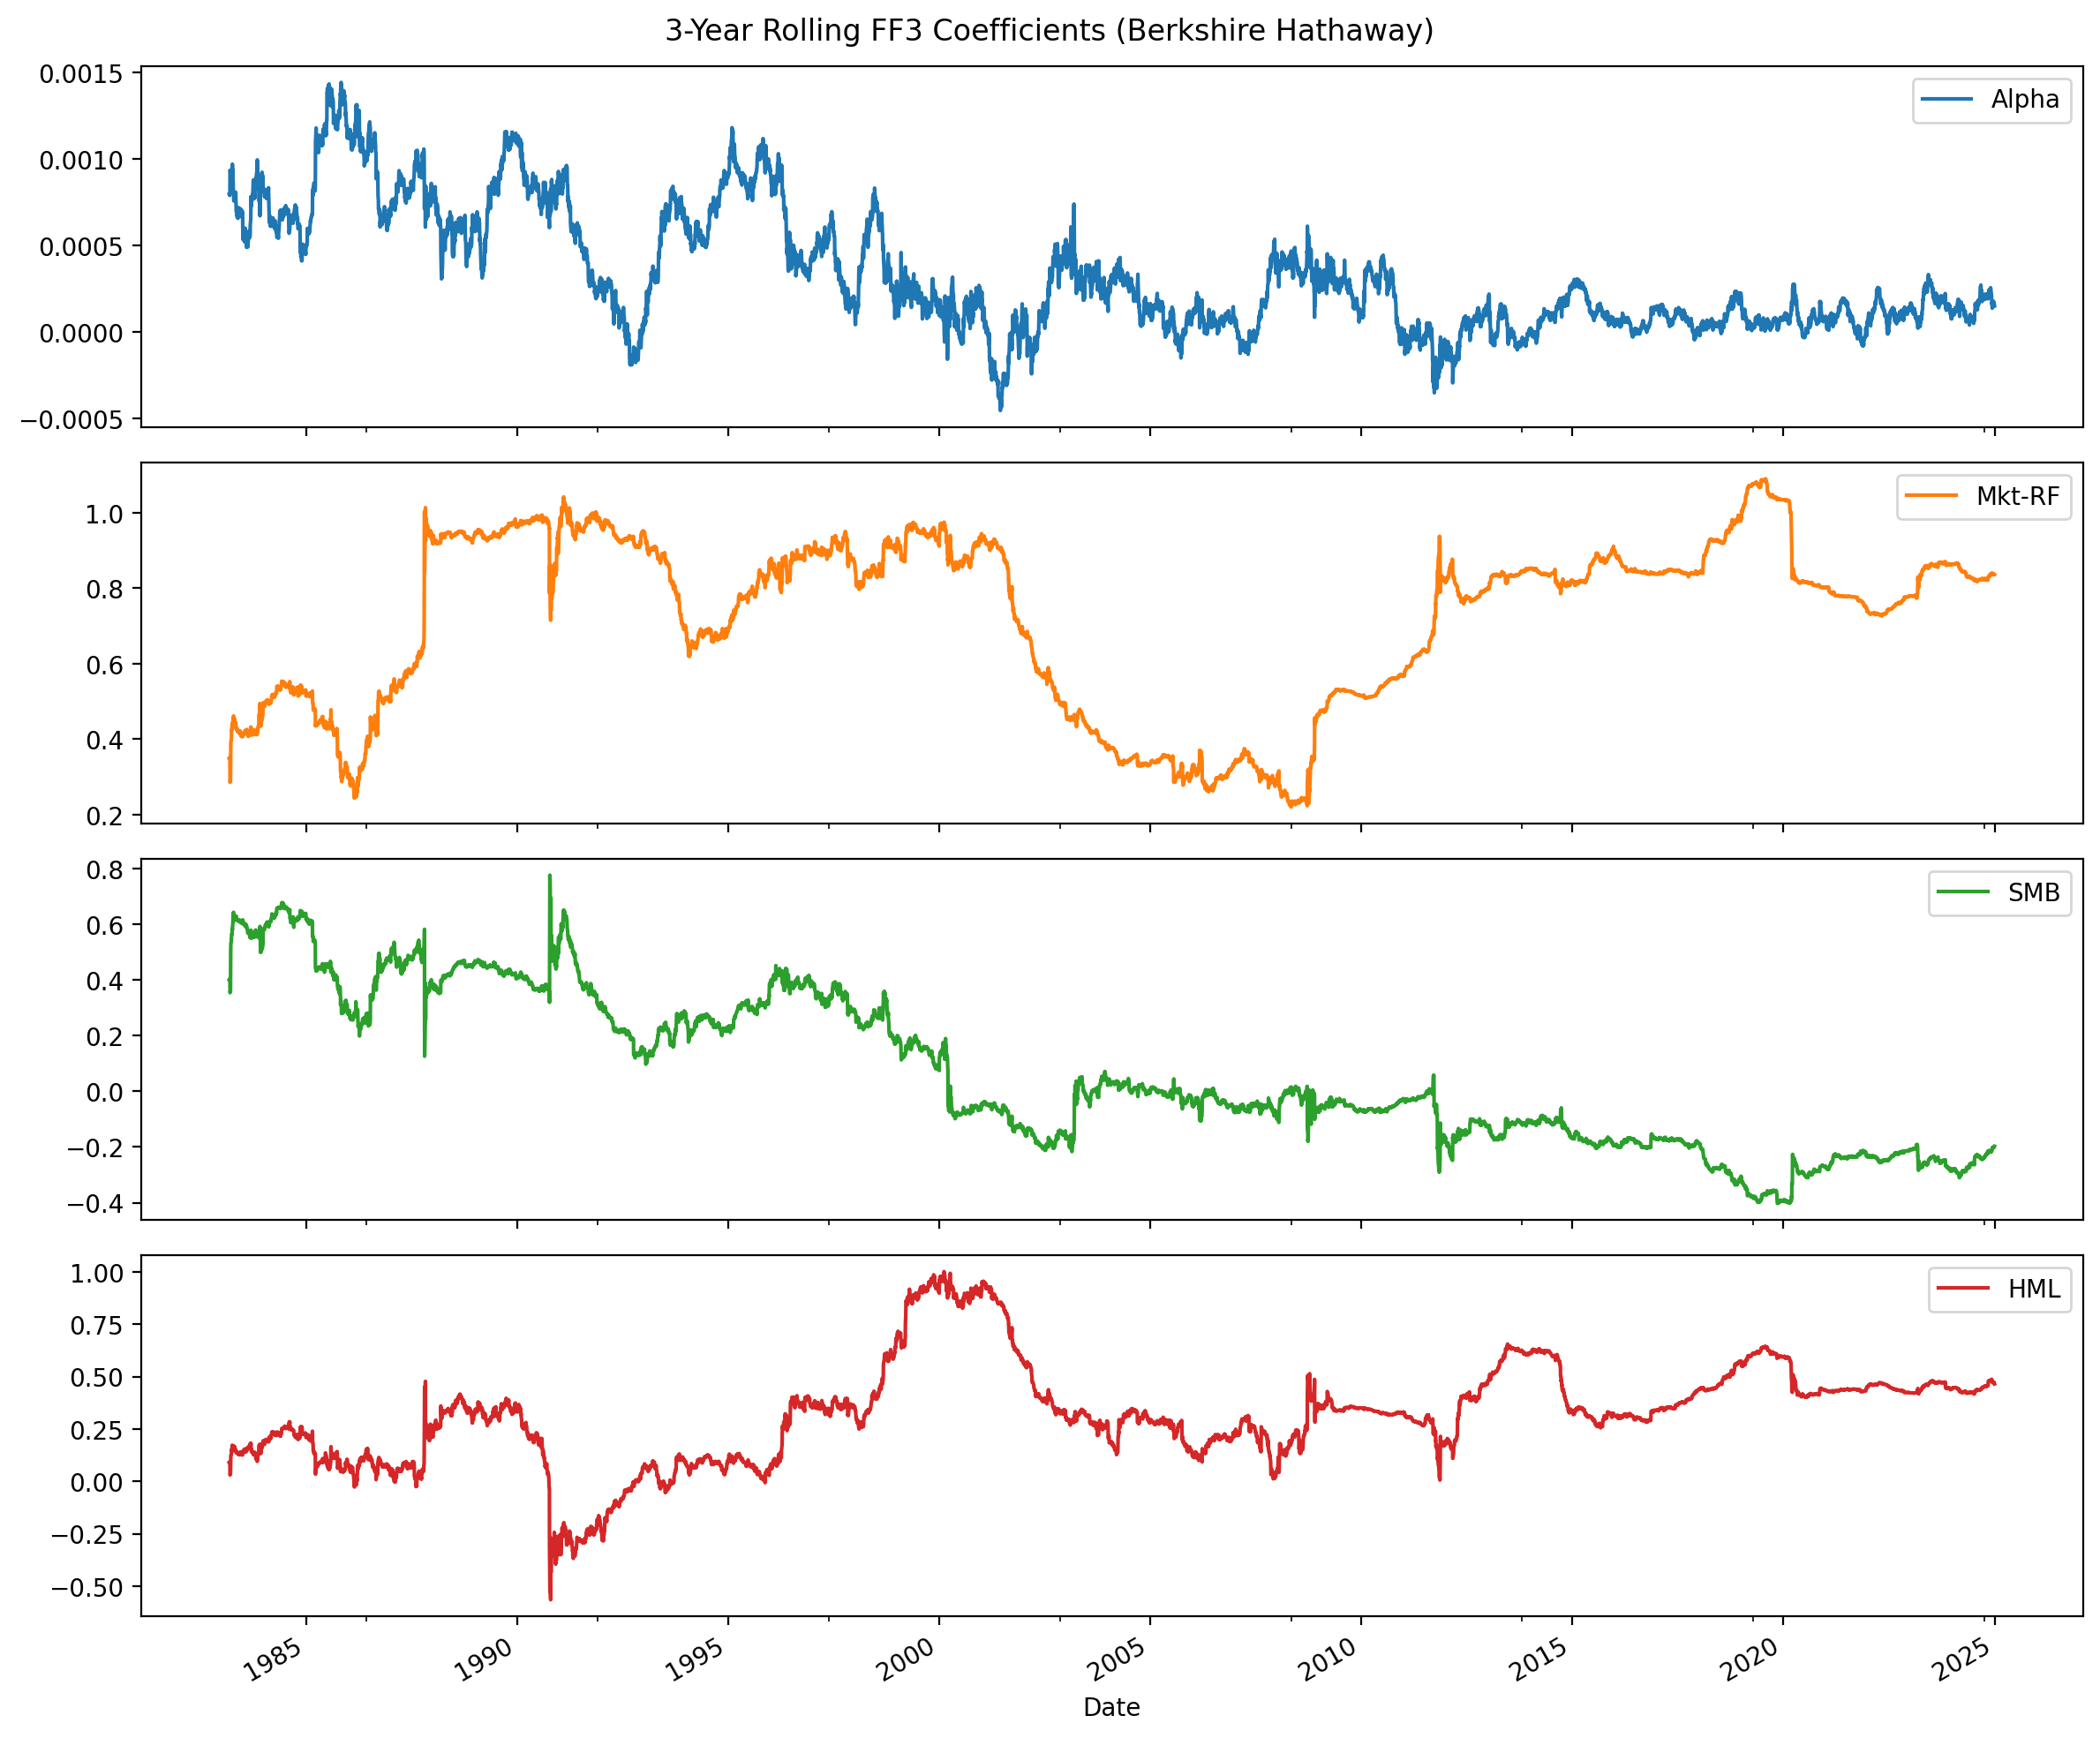

Most successful 3-year period: 1983-07-13 to 1985-08-01


In [14]:
# Download BRK-A daily returns
brk_data = yf.download('BRK-A', start='1965-01-01')[['Close']].pct_change().dropna()
brk_data.columns = ['BRK']

# Download Fama-French 3-Factor daily data
ff_factors = pdr.get_data_famafrench('F-F_Research_Data_Factors_daily', start='1965-01-01')[0]
ff_factors = ff_factors / 100  # Convert to decimal

# Align and merge data
data = brk_data.join(ff_factors, how='inner')
data['Excess'] = data['BRK'] - data['RF']

# Full-sample FF3 regression
X_full = sm.add_constant(data[['Mkt-RF', 'SMB', 'HML']])
model_full = sm.OLS(data['Excess'], X_full).fit()

print(model_full.summary())

# Annualized alpha
daily_alpha = model_full.params['const']
annualized_alpha = daily_alpha * 250
print(f"\nAnnualized Alpha: {annualized_alpha:.4f}")

# --- Rolling regression using RollingOLS ---
window = 750  # 3 years ~ 750 trading days
X_rolling = sm.add_constant(data[['Mkt-RF', 'SMB', 'HML']])
y_rolling = data['Excess']

rolling_model = RollingOLS(endog=y_rolling, exog=X_rolling, window=window)
rolling_results = rolling_model.fit()

# Extract rolling coefficients
coefs = rolling_results.params
coefs.columns = ['Alpha', 'Mkt-RF', 'SMB', 'HML']
coefs = coefs.dropna()

# Plot alpha and betas
coefs.plot(subplots=True, figsize=(12, 10), title='3-Year Rolling FF3 Coefficients (Berkshire Hathaway)')
plt.tight_layout()
plt.show()

# Identify most successful 3-year period
rolling_cum_returns = (data['BRK'] + 1).rolling(window).apply(np.prod, raw=True) - 1
best_period_end = rolling_cum_returns.idxmax()
best_period_start = best_period_end - pd.DateOffset(days=window)

print(f"Most successful 3-year period: {best_period_start.date()} to {best_period_end.date()}")


### PART III

    4. Implement the following three algorithmic trading strategies, using the monthly market return from Ken French's website: 
        1) a 12-month SMA strategy (SMA(12)). Specifically, buy the market when the closing price crosses SMA(12) from below and sell it when the closing price crosses SMA(12) from above.
        2) The same strategy as in 1), but this time you can invest in the risk-free asset if you are not invested in the market.
        3) a 12-month SMA strategy where you short sell. Specifically, buy the market when the closing price is above the SMA(12) and sell it when the closing price is below the SMA(12).
    a. Compare these three strategies with a fouth strategy: buying and holding the market. Which was the best performer?
    b. Which of the four strategies was the best investment?
     (Use statistics and plots to justify your answers.) 

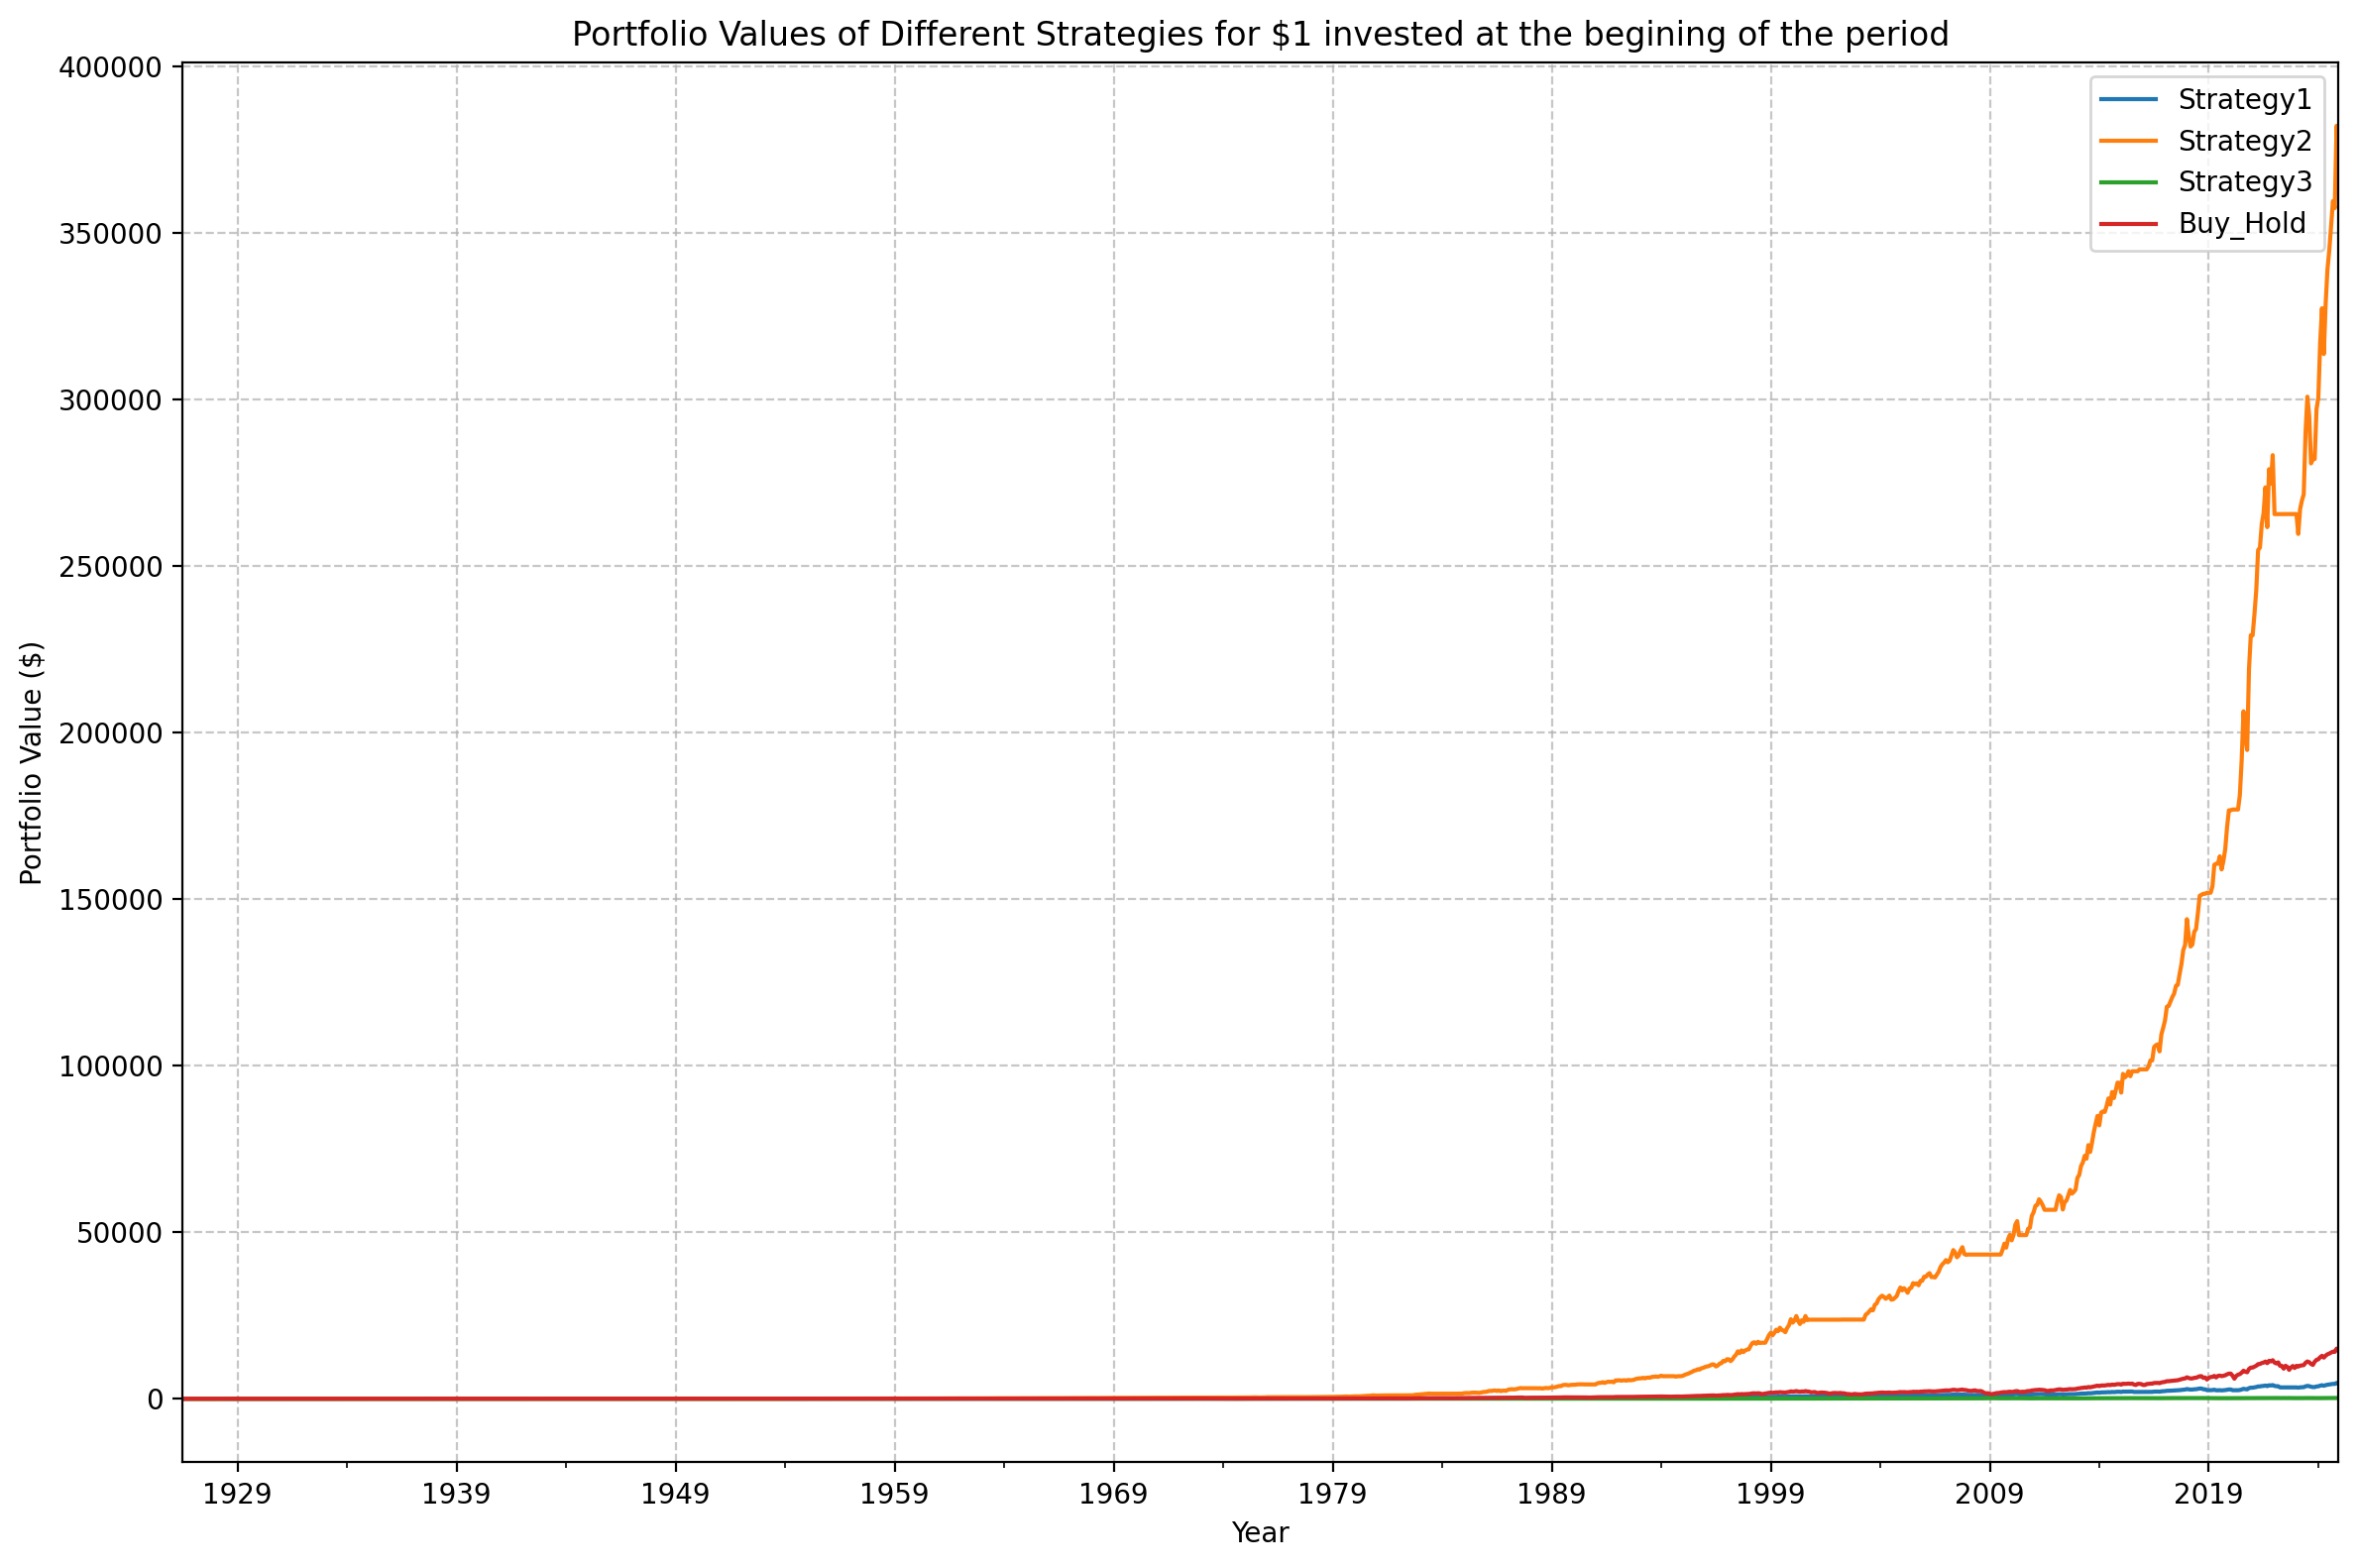

Final portfolio values (prices) of strategies:
Strategy1      4611.69
Strategy2    371504.84
Strategy3       229.86
Buy_Hold      14621.16
Name: 2024-12, dtype: float64
Best performing strategy: Strategy2


In [17]:
# Download monthly market returns and risk-free rate data
ff_factors = pdr.get_data_famafrench('F-F_Research_Data_Factors', start='1926-01-01')[0]
ff_factors /= 100  # Convert percentage to decimal

# Calculate market returns
market_returns = ff_factors['Mkt-RF'] + ff_factors['RF']
rf_returns = ff_factors['RF']

# Calculate portfolio values (index prices) assuming initial investment of $1
portfolio_values = (1 + market_returns).cumprod() * 1  # $1 investment

# Compute the 12-month SMA on portfolio prices (SMA(12))
sma_12 = portfolio_values.rolling(window=12).mean()

# Initialize DataFrame for strategies
strategies = pd.DataFrame(index=market_returns.index)

# Strategy 1: Buy when the portfolio value crosses above SMA(12), sell when crossing below
# Position = 1 when portfolio crosses above SMA, 0 otherwise
strategies['Position1'] = np.where(portfolio_values > sma_12, 1, 0)
strategies['Strategy1'] = (portfolio_values.pct_change() * strategies['Position1'].shift(1))

# Strategy 2: Invest in the market when above SMA(12), invest in the risk-free asset otherwise
# If not in the market, invest in the risk-free asset
strategies['Position2'] = np.where(portfolio_values > sma_12, 1, 0)
strategies['Strategy2'] = np.where(strategies['Position2'] == 1, market_returns, rf_returns)
strategies['Strategy2'] = strategies['Strategy2'] * strategies['Position2'].shift(1)

# Strategy 3: Short sell when the portfolio value is below SMA(12)
# Position = -1 when portfolio is below SMA, 1 when above
strategies['Position3'] = np.where(portfolio_values > sma_12, 1, -1)
strategies['Strategy3'] = (portfolio_values.pct_change() * strategies['Position3'].shift(1))

# Strategy 4: Buy and hold the market
strategies['Buy_Hold'] = market_returns

# Calculate cumulative portfolio values (prices) for all strategies
portfolio_values_strategy1 = (1 + strategies['Strategy1']).cumprod() * 1  # $1 initial investment
portfolio_values_strategy2 = (1 + strategies['Strategy2']).cumprod() * 1  # $1 initial investment
portfolio_values_strategy3 = (1 + strategies['Strategy3']).cumprod() * 1  # $1 initial investment
portfolio_values_buy_hold = (1 + strategies['Buy_Hold']).cumprod() * 1  # $1 initial investment

# Combine all strategies into a single DataFrame for easy plotting
portfolio_values_all = pd.DataFrame({
    'Strategy1': portfolio_values_strategy1,
    'Strategy2': portfolio_values_strategy2,
    'Strategy3': portfolio_values_strategy3,
    'Buy_Hold': portfolio_values_buy_hold
}, index=market_returns.index)

# Plot portfolio values (prices over time) for each strategy
portfolio_values_all.plot(figsize=(12, 8), title='Portfolio Values of Different Strategies for $1 invested at the begining of the period')
plt.xlabel('Year')
plt.ylabel('Portfolio Value ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Calculate final portfolio values (prices) for each strategy
final_values = portfolio_values_all.iloc[-1]
print("Final portfolio values (prices) of strategies:")
print(final_values.round(2))

# Determine best performing strategy
best_strategy = final_values.idxmax()
print(f"Best performing strategy: {best_strategy}")


### (a)
- Strategy 1 (SMA(12) without risk-free asset):
  - Final portfolio value: $4,611.69
  - The strategy performs poorly compared to others. Despite the potential for market timing, the value doesn't grow significantly.

- Strategy 2 (SMA(12) with risk-free asset):
  - Final portfolio value: $371,504.84
  - This strategy is the best performer by far. The inclusion of the risk-free asset likely reduced the downside during volatile periods, contributing to its strong performance over time.

- Strategy 3 (SMA(12) with short selling):
  - Final portfolio value: $229.86
  - This strategy performs very poorly, likely due to the challenges and risks associated with short selling, especially in a market with prolonged uptrends.

- Buy & Hold Strategy:
  - Final portfolio value: $14,621.16
  - The Buy & Hold strategy performs better than Strategy 1 and Strategy 3, but significantly worse than Strategy 2.

Best Performing Strategy:
- Strategy 2 (SMA(12) with risk-free asset)** is the best performer with a final portfolio value of $371,504.84.
  - This strategy benefited from reduced risk through the ability to invest in the risk-free asset during unfavorable market conditions, leading to the highest portfolio value at the end of the period.

### (b)
- Strategy 2 (SMA(12) with risk-free asset)** is the best investment. This strategy provided the highest return due to its ability to shift between market investments and risk-free assets, offering a balanced approach to risk management and returns.